<h2>Used motorcycle price prediction


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import itertools

np.random.seed(42)

In [37]:
df=pd.read_csv('./datasets/used_bikes.csv')

In [40]:
df.info()
df.head()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Lot No.      500 non-null    float64
 1   Engine Size  500 non-null    float64
 2   Mileage      500 non-null    float64
 3   KM Run       500 non-null    float64
 4   Max Power    500 non-null    float64
 5   Price        500 non-null    float64
dtypes: float64(6)
memory usage: 23.6 KB


,Lot No.,Engine Size,Mileage,KM Run,Max Power,Price
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.028943,-0.098844,0.011978,0.060914,0.290871,49.271645
std,1.016772,0.974530,1.037278,1.013258,1.988121,16.567155
min,-2.983970,-3.051313,-2.570978,-2.720897,-5.797945,0.000000
25%,-0.628825,-0.754901,-0.713869,-0.557405,-1.055721,38.781717
50%,0.044120,-0.145722,0.009085,0.059825,0.203102,49.871182
75%,0.741279,0.595638,0.759851,0.720886,1.687999,59.135314
max,3.625287,2.811878,3.702458,3.173982,6.536713,100.000000


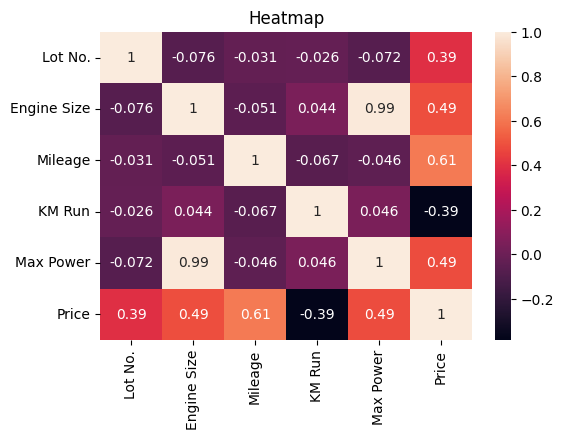

In [42]:
import seaborn as sn
fig=plt.figure(figsize=(6,4))
corel=df.corr()
sn.heatmap(corel, annot=True)
plt.title("Heatmap")
plt.show()

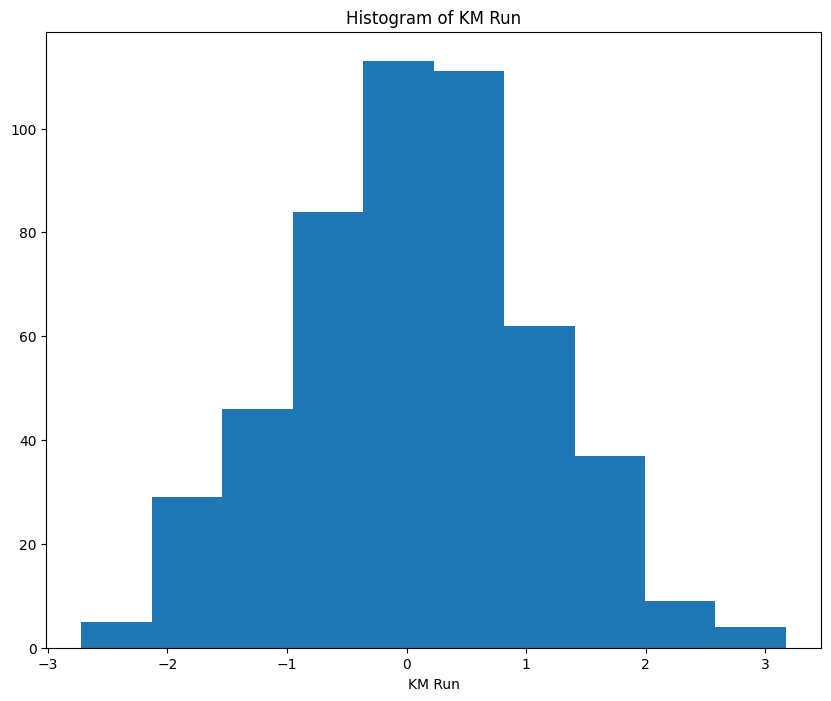

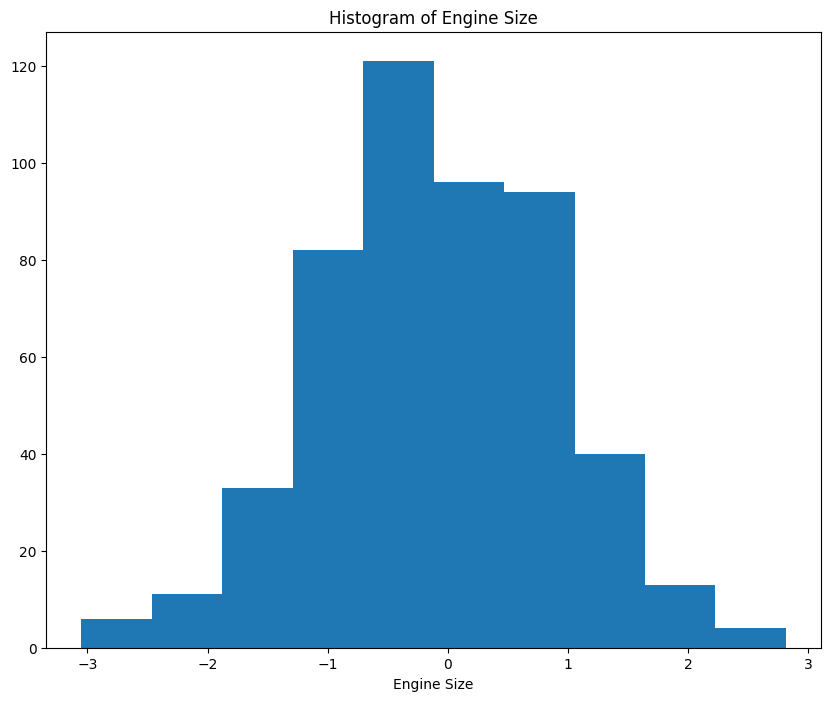

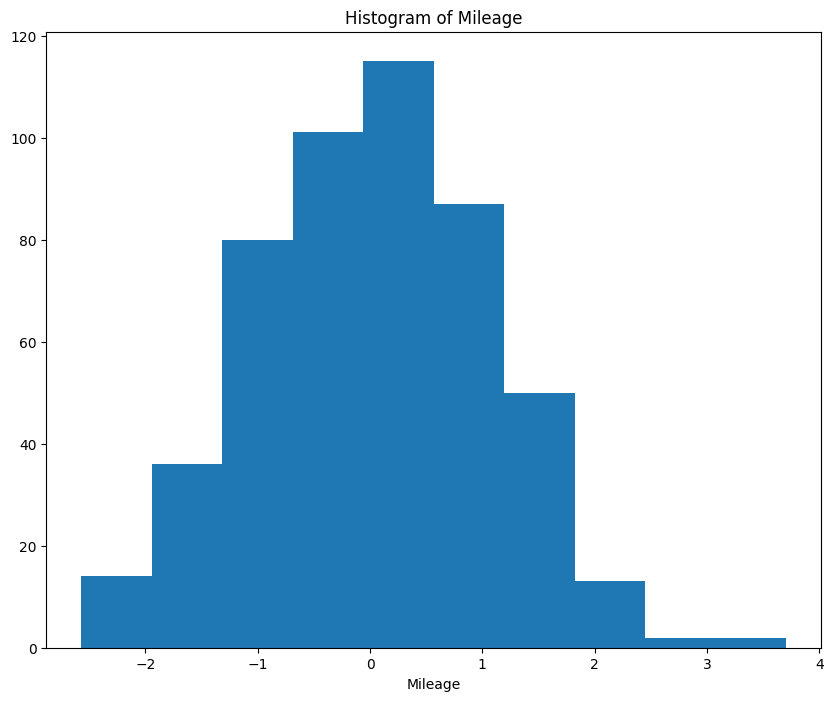

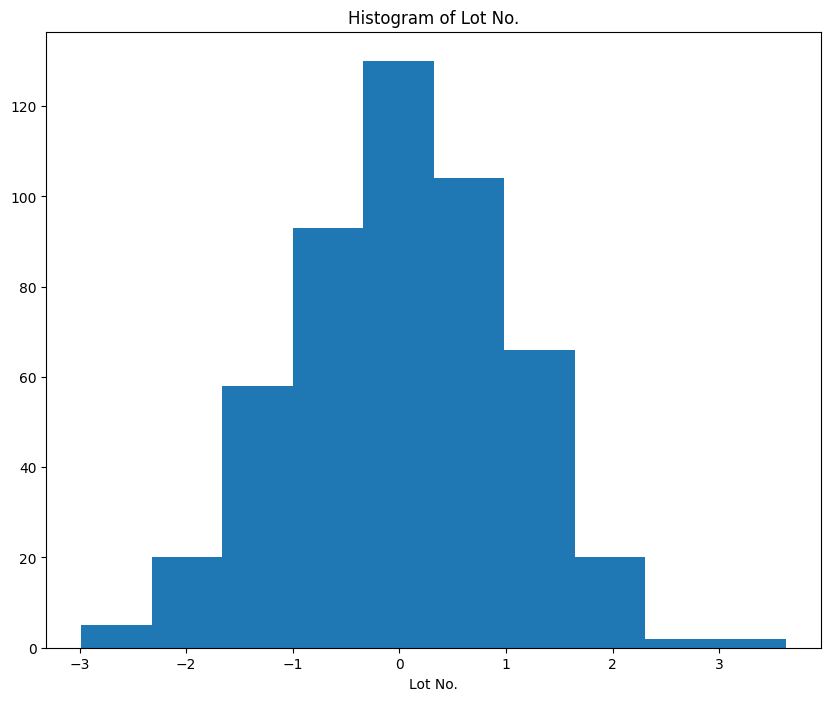

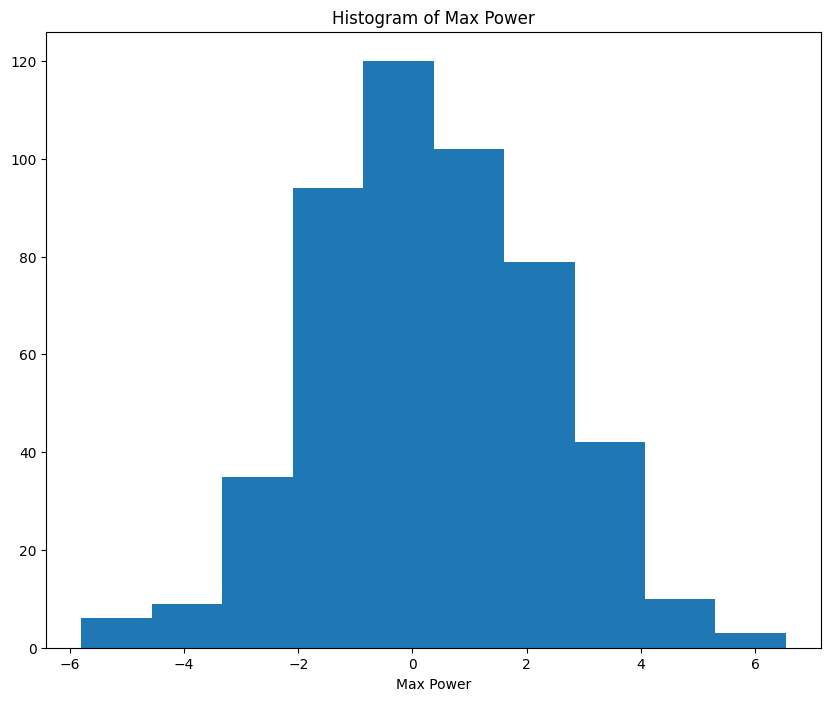

In [ ]:
for y in (set(df.columns) - {"Price"}):
    fig = plt.figure(figsize=(10, 8))
    plt.hist(x=df[y])
    plt.xlabel(y)
    plt.title(f"Histogram of {y}")
    plt.show()

In [ ]:

X = df.drop("Price", axis=1). values
y = df[ "Price"]. values.reshape(X.shape[0],1)
df.head()

,Lot No.,Engine Size,Mileage,KM Run,Max Power,Price
0,0.056646,-1.043517,0.797331,-0.222694,-1.863743,45.026610
1,0.238778,-0.417864,0.000508,0.866960,-0.312565,39.300833
2,-1.492397,0.936633,0.785432,-0.091035,2.423967,58.923446
3,1.132288,-0.583562,0.790543,1.262054,-1.121522,52.101286
4,1.318906,2.024895,0.996975,1.427730,4.410519,79.322492


In [ ]:
model =LinearRegression().fit(X,y)
residuals = model.predict(X) -y

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

VIF = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
print(VIF)

[np.float64(1.0087076423300196), np.float64(12.616827778300836), np.float64(1.0089247045274492), np.float64(1.0103881947486888), np.float64(12.603910494981058)]


In [ ]:
X=np.delete(X,4,1)

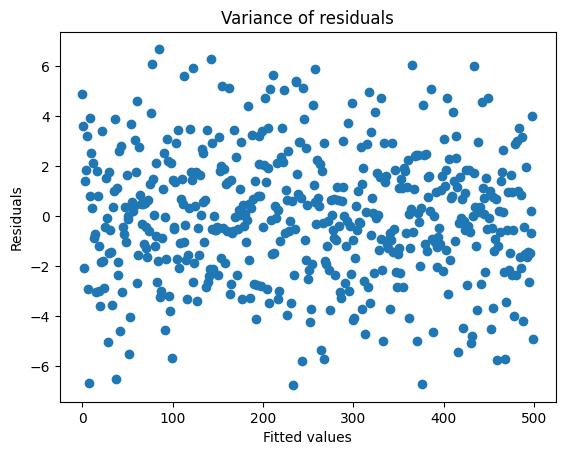

In [ ]:
X_axis = range (500)
y_axis = residuals
plt.scatter(x=X_axis,y=y_axis)
plt.title("Variance of residuals")
plt.xlabel("Fitted values")
plt.ylabel("Residuals") 
plt.show()

In [ ]:
from statsmodels.stats.stattools import durbin_watson

durbin_watson_score = durbin_watson(residuals)
print(durbin_watson_score)

[2.07164064]


In [ ]:
import statsmodels.api as sm
p_value =sm.stats.normal_ad(residuals)[1]
print(p_value)

[0.85673401]


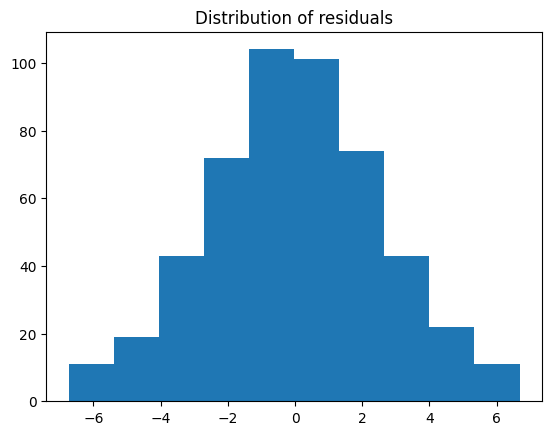

In [ ]:
plt.title("Distribution of residuals")
plt.hist(residuals)
plt.show()

<h2>Train

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [ ]:
def adjusted_2_score(y_test, y_pred):
    n = X.shape[0]
    d = X.shape[1]
    from sklearn.metrics import r2_score
    r2 = r2_score(y_test, y_pred)
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - d - 1))
    return adj_r2

In [ ]:
np.random.seed(42)
y_test_test= np.random.randn(12,1)
y_pred_test = y_test_test + 1

assert adjusted_2_score(y_test_test, y_pred_test) <= 0

In [ ]:
feature_combinations = []

for L in range(1, X.shape[1] + 1):
    for subset in itertools.combinations(range(X.shape[1]), L):
        feature_combinations.append(list(subset))

for features in feature_combinations:
    X_train_temp = X_train[:, features]
    X_test_temp = X_test[:, features]
    
    linear_regression = LinearRegression()
    linear_regression.fit(X_train_temp, y_train)
    
    y_pred = linear_regression.predict(X_test_temp)
    adj_r2 = adjusted_2_score(y_test, y_pred)
    models = dict()
    models_r2 = dict()
    models[str(features)] = np.c_[linear_regression.intercept_, linear_regression.coef_]
    models_r2[str(features)] = adj_r2

print("Different linear regression models and their adjusted r2 score")
for key in models_r2.keys():
    print("{} : {}".format(key, models_r2[key]))

best = max(models_r2, key=models_r2.get)
print("Best model: {} Parameters: {}".format(best, models[best]))

Different linear regression models and their adjusted r2 score
[0, 1, 2, 3] : 0.9744322614168767
Best model: [0, 1, 2, 3] Parameters: [[50.25299626  7.25576172  9.57649649 10.0929504  -6.006947  ]]


In [ ]:
from sklearn.linear_model import Ridge
ridge_regression = Ridge(alpha=1.0)
ridge_regression.fit(X_train, y_train)
y_pred_ridge = ridge_regression.predict(X_test)
r2= r2_score(y_test, y_pred)

print("Ridge Regression R2 Score: ", r2)

Ridge Regression R2 Score:  0.9746372132291662


In [ ]:
from sklearn.linear_model import Lasso
lasso_regression = Lasso(alpha=0.1)
lasso_regression.fit(X_train, y_train)
y_pred_lasso = lasso_regression.predict(X_test)
r2_lasso = r2_score(y_test, y_pred_lasso)
print("Lasso Regression R2 Score: ", r2_lasso)

Lasso Regression R2 Score:  0.9746938727570693
